# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alikadirguzel/flyrankinternship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

**Lane 2 — Refresh / Content Opportunity Scoring.** Week 4 gave me a written rule that ranks pages for review. This notebook trains models on the *same* rows, the *same* label and the *same* client-holdout split, and puts them in one table next to that rule. Then it reads the errors before believing the score.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

My lane answers **"which page does an editor open first?"** — that is a *ranking* question, not a yes/no question. So the shape of the method is fixed by the shape of the decision:

> train a classifier on the decline proxy → take its **probability** → sort → measure **Precision@50** (one editor sprint ≈ 50 pages).

A label (`0/1`) cannot be sorted; a probability can. That single choice is why every model below is scored at the top of a list, not on accuracy over 30,000 rows.

**Which learners, and in what order — simple first:**

| Model | Why it is in the run | What it costs |
|---|---|---|
| **Logistic Regression** | readable, gives a calibrated-ish monotone score, tells me the *direction* of each signal | cannot express "low CTR **only when** position is good" |
| **Decision tree, depth 3** | I can print the whole thing and read it as a rule — it is the honest upgrade of my Week-4 if-statements | coarse; a few splits throw away most of the ordering inside a leaf |
| **Random Forest** | the interactions this lane is full of (CTR × position, staleness × visibility) are exactly what trees combine | not readable on its own — needs permutation importance |
| **Hist Gradient Boosting** | "gradient boosting where safe": same table, same split, so I can see whether the extra machinery actually buys anything | easiest place to fool myself; it only stays if it wins by more than fold noise |

Complexity has to *earn* its place: I select the model on **cross-validated Precision@50 over training clients**, and if a simpler model lands inside the fold-to-fold noise of a stronger one, I say so and prefer the simple one.

**Two methods from the menu I use as instruments, not as the product:**
- **Permutation importance** (section 4) — feature importance read off a fit is a story; shuffling a column on the holdout and watching the metric fall is a measurement.
- **K-Means** (section 4) — not to predict anything, but to name the *kinds of work* sitting in the top of the queue, so the ranked list can carry an action next to each page.

**Methods I deliberately did not pick:** a time-series/forecast model (this starter CSV is one trailing-90-day snapshot; it has no date column to forecast along) and anything causal (nothing here records an intervention, so I cannot claim a refresh *causes* recovery — the output is decision support for review order).

**The label and the honest caveat.** `is_declining_label = (trend_direction == "down")`, i.e. last-30-day impressions fell more than 20% versus the previous 30 days. That is an *observed current-window movement bucket*, not a future outcome. So every number below reads as "the model ranks pages that already moved down to the top", not "the model predicts next month". The warehouse version of this lane (past window → later window) is the Week-6 job.

In [1]:
# ---- Setup: same CSV, same lane slice, same label as Week 4 -------------------------
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42     # every split, model and shuffle below uses this seed
K = 50                # editor capacity -> the metric is Precision@50

candidates = [
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("../data/raw/content_refresh_anonymized.csv"),
    Path("../../data/raw/content_refresh_anonymized.csv"),
    Path("flyrankinternship/data/raw/content_refresh_anonymized.csv"),
]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    if not Path("flyrankinternship").exists():
        get_ipython().system("git clone -q https://github.com/alikadirguzel/flyrankinternship.git")
    data_path = Path("flyrankinternship/data/raw/content_refresh_anonymized.csv")

df_raw = pd.read_csv(data_path)

REPO_ROOT = data_path.resolve().parents[2]
OUT_DIR = REPO_ROOT / "work" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Lane 2 slice, identical to the framing notebook: measurable search history, 90-day-old content.
lane = df_raw[(df_raw["impressions_90d"] > 0) & (df_raw["content_age_days"] >= 90)].copy()
lane["is_declining_label"] = (lane["trend_direction"] == "down").astype(int)
lane = lane.reset_index(drop=True)

print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"seed: {RANDOM_STATE}   |   K (editor capacity): {K}")
print()
print(f"rows (pages): {len(lane):,}   clients: {lane['client_id'].nunique()}   duplicate pages: {int(lane['content_id'].duplicated().sum())}")
print(f"label = (trend_direction == 'down')   base rate: {lane['is_declining_label'].mean():.4f}")
print(f"a random top-{K} would therefore be right about {lane['is_declining_label'].mean() * K:.0f} times out of {K}")

python 3.12.10 | pandas 2.3.3 | numpy 1.26.4 | scikit-learn 1.7.2
seed: 42   |   K (editor capacity): 50

rows (pages): 30,000   clients: 32   duplicate pages: 0
label = (trend_direction == 'down')   base rate: 0.5421
a random top-50 would therefore be right about 27 times out of 50


### The method menu, scored against my question

Before writing model code, the menu from the live session against the shape of *this* question.

In [2]:
method_table = pd.DataFrame(
    [
        ("which page first? (the product)", "classifier probability -> sort -> Precision@50",
         "CHOSEN — a ranking needs a score, not a label"),
        ("is this page declining? (the scorer underneath)", "Logistic Regression -> Decision Tree -> Random Forest -> Hist Gradient Boosting",
         "CHOSEN — readable first, stronger only if it wins"),
        ("what does the score lean on?", "permutation importance on the holdout",
         "CHOSEN — a fit's importances are a story; shuffling is a measurement"),
        ("what kind of work is in the queue?", "K-Means on the top of the queue, clusters named by hand",
         "CHOSEN — for action archetypes, not for prediction"),
        ("how do signals move together?", "correlation / signal audit",
         "already done in Week 4 — reused here as the feature short-list"),
        ("what will traffic be next month?", "time-series forecast",
         "REJECTED — this CSV is one trailing-90-day snapshot, there is no date axis"),
        ("does refreshing a page cause recovery?", "causal / experimental design",
         "REJECTED — no intervention is recorded; I only claim review order"),
    ],
    columns=["question shape", "method", "verdict"],
)
display(method_table)

,question shape,method,verdict
0,which page first? (the product),classifier probability -> sort -> Precision@50,"CHOSEN — a ranking needs a score, not a label"
1,is this page declining? (the scorer underneath),Logistic Regression -> Decision Tree -> Random...,"CHOSEN — readable first, stronger only if it wins"
2,what does the score lean on?,permutation importance on the holdout,CHOSEN — a fit's importances are a story; shuf...
3,what kind of work is in the queue?,"K-Means on the top of the queue, clusters name...","CHOSEN — for action archetypes, not for predic..."
4,how do signals move together?,correlation / signal audit,already done in Week 4 — reused here as the fe...
5,what will traffic be next month?,time-series forecast,REJECTED — this CSV is one trailing-90-day sna...
6,does refreshing a page cause recovery?,causal / experimental design,REJECTED — no intervention is recorded; I only...


### What the model may look at — and what it may never look at

The exclusion list is the important half. `trend_direction` **is** the label, `trend_pct` is what the label is bucketed from, and `impressions_last_30d` / `impressions_prev_30d` are the two numbers `trend_pct` is computed from. I also drop the *sibling* last-30/prev-30 click and session windows: they are measured over exactly the same two windows as the label, so they are the same information wearing a different name. Section 4 puts a number on what happens if I let them in.

Missingness here is **systematic, not random** (keyword fields are empty along `content_type` lines, `word_count` is missing for ~26% of rows, `avg_position = 0` means "no position data"). A blind `fillna(0)` would quietly encode content type into the features, so instead: `0 → NaN` for position, median imputation inside the pipeline, and explicit `has_*` flags that let the model use *"this is missing"* as a signal on purpose rather than by accident.

In [3]:
CATEGORICAL_FEATURES = ["content_type", "main_intent", "competition_level"]


def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Signals an editor could see at review time. No label, no label ingredient, no id."""
    f = pd.DataFrame(index=frame.index)

    # demand / visibility (heavy-tailed -> log1p)
    f["log_impressions_90d"] = np.log1p(frame["impressions_90d"])
    f["log_clicks_90d"] = np.log1p(frame["clicks_90d"])
    f["log_sessions_90d"] = np.log1p(frame["sessions_90d"])
    f["log_pageviews_90d"] = np.log1p(frame["pageviews_90d"])
    f["log_ai_sessions_90d"] = np.log1p(frame["ai_sessions_90d"])

    # search quality: avg_position == 0 means "no data", not rank zero
    position = frame["avg_position"].replace(0, np.nan)
    f["avg_position"] = position
    f["has_position_data"] = position.notna().astype(int)
    f["ctr"] = frame["ctr"]                      # x100 percentage: 0.76 == 0.76%

    # how consistently the page shows up at all
    f["days_with_impressions"] = frame["days_with_impressions"]
    f["days_with_sessions"] = frame["days_with_sessions"]
    f["impressions_per_active_day"] = frame["impressions_90d"] / frame["days_with_impressions"].clip(lower=1)

    # engagement (GA4) — flagged, because zero sessions is not zero engagement
    f["engagement_rate"] = frame["engagement_rate"]
    f["scroll_rate"] = frame["scroll_rate"]
    f["ai_traffic_pct"] = frame["ai_traffic_pct"]
    f["has_ga4_sessions"] = (frame["sessions_90d"] > 0).astype(int)

    # content shape and freshness
    f["word_count"] = frame["word_count"]
    f["has_word_count"] = frame["word_count"].notna().astype(int)
    f["content_age_days"] = frame["content_age_days"]
    f["days_since_last_update"] = frame["days_since_last_update"]
    f["stale_share_of_life"] = frame["days_since_last_update"] / frame["content_age_days"].clip(lower=1)

    # keyword context — missing along content_type lines, so it travels with a flag
    f["log_search_volume"] = np.log1p(frame["search_volume"])
    f["competition"] = frame["competition"]
    f["cpc"] = frame["cpc"]
    f["has_keyword_data"] = frame["search_volume"].notna().astype(int)

    for column in CATEGORICAL_FEATURES:
        f[column] = frame[column].fillna("unknown").astype(str)

    return f


X_all = build_features(lane)
y_all = lane["is_declining_label"].to_numpy()
NUMERIC_FEATURES = [c for c in X_all.columns if c not in CATEGORICAL_FEATURES]

excluded = pd.DataFrame(
    [
        ("trend_direction", "THE LABEL — the target is literally this column bucketed"),
        ("trend_pct", "label ingredient — trend_direction is cut from it at -20%"),
        ("impressions_last_30d, impressions_prev_30d", "the two numbers trend_pct is computed from"),
        ("clicks_last_30d, clicks_prev_30d, sessions_last_30d, sessions_prev_30d",
         "same last-30 vs prev-30 windows as the label; the label wearing another name"),
        ("content_id, client_id", "pseudonymous ids — grouping and splitting only, never features"),
        ("provider_used, model_used", "generation metadata; the data dictionary marks it not-a-feature"),
        ("age_tier, freshness_tier, *_tier", "threshold restatements of numerics already passed in"),
    ],
    columns=["dropped column(s)", "why it can never be a feature"],
)

print(f"features the model sees: {X_all.shape[1]}  ({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)")
print()
print("missingness the pipeline must handle on purpose (NaN count in the feature frame):")
missing = X_all[NUMERIC_FEATURES].isna().sum()
display(missing[missing > 0].to_frame("missing_rows").assign(share=lambda d: (d.missing_rows / len(X_all)).round(3)))

print("word_count missingness is systematic — it follows content_type:")
display(
    lane.assign(word_count_missing=lane["word_count"].isna())
    .groupby("content_type")["word_count_missing"]
    .agg(["size", "mean"])
    .rename(columns={"size": "rows", "mean": "share_missing"})
    .round(3)
)

print("the exclusion list (the important half):")
display(excluded)

leak_columns = ["trend_direction", "trend_pct", "impressions_last_30d", "impressions_prev_30d",
                "clicks_last_30d", "clicks_prev_30d", "sessions_last_30d", "sessions_prev_30d",
                "is_declining_label", "content_id", "client_id"]
present = [c for c in leak_columns if c in X_all.columns]
print(f"\ncheck — banned columns present in the feature frame: {present if present else 'none'}")

features the model sees: 27  (24 numeric + 3 categorical)

missingness the pipeline must handle on purpose (NaN count in the feature frame):


,missing_rows,share
avg_position,1205,0.040
scroll_rate,125,0.004
word_count,7699,0.257
log_search_volume,2468,0.082
competition,2468,0.082
cpc,2468,0.082


word_count missingness is systematic — it follows content_type:


,rows,share_missing
content_type,,
comparison article,697,0.000
feedly article,2096,0.000
keyword article,27207,0.283


the exclusion list (the important half):


,dropped column(s),why it can never be a feature
0,trend_direction,THE LABEL — the target is literally this colum...
1,trend_pct,label ingredient — trend_direction is cut from...
2,"impressions_last_30d, impressions_prev_30d",the two numbers trend_pct is computed from
3,"clicks_last_30d, clicks_prev_30d, sessions_las...",same last-30 vs prev-30 windows as the label; ...
4,"content_id, client_id",pseudonymous ids — grouping and splitting only...
5,"provider_used, model_used",generation metadata; the data dictionary marks...
6,"age_tier, freshness_tier, *_tier",threshold restatements of numerics already pas...



check — banned columns present in the feature frame: none


## 2. Split design

**Grouped by client. Eight whole clients (25% of clients, 19% of pages) held out, seed 42; no page from a test client is ever seen in training.**

Why grouped and not random rows: pages of one client share a CMS, a template, a topic space, one publishing cadence and one Search Console property. Their decline rates move together — the per-client positive rate below spans a wide band, not a tight one around the 54% average. With a random row split, a model can recognise "this row smells like client X" from ordinary features (volume scale, word-count style, keyword mix) and inherit that client's base rate for free. That is not a page-level insight, and it evaporates on the next client that signs up. Grouping by client forces the question I actually care about: **does this ranking transfer to a site the model has never seen?**

**Why not time-aware:** this starter CSV is a single trailing-90-day snapshot with no date column — there is no time axis to split along. The label window (last 30 days) is the most recent slice of that same snapshot, which is exactly why every last-30/prev-30 column stays out of the features. A real past→future split needs the warehouse daily facts; that is the Week-6 notebook, and I will not pretend to have it here.

**Two-level design, so the holdout is touched once:**
1. **Model selection** — `GroupKFold(5)` over the 24 training clients. Every fold's validation set is a set of whole, unseen clients. I pick the model on the mean Precision@50 across those folds, and I keep the spread, because a single 50-page slice is a noisy number.
2. **Reporting** — the 8 held-out clients are scored exactly once, at the end, for every row of the comparison table (baseline included).

The rule baseline is scored on the *same* rows with the *same* metric. Its percentile ranks are recomputed inside whichever slice is being ranked, because that is what a strategist with only those clients in front of them would do.

Section 3 also re-runs the winning model on an optimistic random-row split so the cost of this honesty is a number, not a claim.

In [4]:
from sklearn.model_selection import GroupKFold

clients = np.sort(lane["client_id"].unique())
rng = np.random.default_rng(RANDOM_STATE)
n_test_clients = max(1, int(round(0.25 * len(clients))))
test_clients = set(rng.permutation(clients)[:n_test_clients])

lane["split"] = np.where(lane["client_id"].isin(test_clients), "test", "train")
train_mask = (lane["split"] == "train").to_numpy()
test_mask = ~train_mask

X_train, X_test = X_all[train_mask], X_all[test_mask]
y_train, y_test = y_all[train_mask], y_all[test_mask]
groups_train = lane.loc[train_mask, "client_id"].to_numpy()

overlap = set(lane.loc[train_mask, "client_id"]) & set(lane.loc[test_mask, "client_id"])
print(f"clients: {len(clients)} total -> {len(clients) - n_test_clients} train / {n_test_clients} test")
print(f"client overlap between train and test (must be empty): {overlap if overlap else 'none'}")
print(f"rows:  train {train_mask.sum():,}   test {test_mask.sum():,}   ({test_mask.mean():.1%} of pages held out)")
print(f"base rate:  train {y_train.mean():.3f}   test {y_test.mean():.3f}   (all rows {y_all.mean():.3f})")
print()

per_client = (
    lane.groupby("client_id")
    .agg(pages=("content_id", "size"), positive_rate=("is_declining_label", "mean"), split=("split", "first"))
    .sort_values("positive_rate")
)
print("per-client positive rate — the reason a random row split would flatter the model:")
print(f"  lowest client:  {per_client['positive_rate'].min():.3f}")
print(f"  highest client: {per_client['positive_rate'].max():.3f}")
print(f"  spread across {len(per_client)} clients: {per_client['positive_rate'].max() - per_client['positive_rate'].min():.3f}")
print(f"  page counts per client: min {per_client['pages'].min():,}  median {int(per_client['pages'].median()):,}  max {per_client['pages'].max():,}")
print()
print("held-out clients (8) — sizes and label rates, ids shown only as short hashes:")
display(
    per_client[per_client["split"] == "test"]
    .assign(client=lambda d: [c[-6:] for c in d.index])
    .reset_index(drop=True)[["client", "pages", "positive_rate"]]
    .round(3)
)

cv = GroupKFold(n_splits=5)
folds = list(cv.split(X_train, y_train, groups=groups_train))
fold_rows = []
for i, (tr_idx, va_idx) in enumerate(folds, start=1):
    fold_rows.append(
        {
            "fold": i,
            "train_clients": len(np.unique(groups_train[tr_idx])),
            "val_clients": len(np.unique(groups_train[va_idx])),
            "val_rows": len(va_idx),
            "val_base_rate": round(float(y_train[va_idx].mean()), 3),
        }
    )
print("GroupKFold(5) over the 24 training clients — whole clients per fold:")
display(pd.DataFrame(fold_rows))
print("every fold's validation clients are unseen in that fold's training half; the 8 test clients appear in none of them.")

clients: 32 total -> 24 train / 8 test
client overlap between train and test (must be empty): none
rows:  train 24,374   test 5,626   (18.8% of pages held out)
base rate:  train 0.538   test 0.558   (all rows 0.542)

per-client positive rate — the reason a random row split would flatter the model:
  lowest client:  0.000
  highest client: 0.937
  spread across 32 clients: 0.937
  page counts per client: min 3  median 567  max 7,008

held-out clients (8) — sizes and label rates, ids shown only as short hashes:


,client,pages,positive_rate
0,4232cd,649,0.194
1,5e3a26,1106,0.220
2,4c6ff0,254,0.386
3,ced1de,43,0.419
4,fabef1,1031,0.542
5,ab7c34,118,0.619
6,f1b21c,158,0.766
7,a35f04,2267,0.839


GroupKFold(5) over the 24 training clients — whole clients per fold:


,fold,train_clients,val_clients,val_rows,val_base_rate
0,1,23,1,7008,0.490
1,2,18,6,4303,0.630
2,3,20,4,4300,0.476
3,4,19,5,4440,0.626
4,5,16,8,4323,0.497


every fold's validation clients are unseen in that fold's training half; the 8 test clients appear in none of them.


## 3. Train + compare vs my baseline

**The baseline is my Week-4 rule, recomputed in this notebook run** — same weights, same reason codes, restated as one function so nobody has to trust a number carried over from another session:

```text
baseline_refresh_score =
      0.40 * visibility            (percentile rank of log impressions_90d)
    + 0.30 * freshness_risk        (percentile rank of days_since_last_update)
    + 0.25 * position_opportunity  ((1 - normalised position) * visibility, 0 when position is missing)
    + 0.05 * depth_gap             ((1 - percentile rank of word_count) * visibility)
```

One deliberate change from the reference rule: its `declining_with_demand` reason code reads `trend_direction == "down"`, which is the label. A baseline that reads the answer key is not a baseline, so that clause is gone from both the score and the reason codes.

**Two reference rows are in the table for scale:** a seeded random shuffle (what luck alone buys) and the test base rate (what "always say declining" buys). Every row is scored on the **same 8 held-out clients** with the **same** ranking metrics.

**Metrics, and what each is for:**
- **Precision@50** — the decision metric: of the 50 pages an editor actually opens, how many were really declining.
- **Precision@20 / @100** — one sprint shorter, one longer. If a model wins at 50 and loses at 20, that IS the finding, and it must be visible.
- **Recall@50** — the share of all declining pages a 50-page sprint touches. On ~5.6k test pages this is necessarily tiny; it is here to keep the top-50 number in proportion.
- **ROC-AUC / average precision** — whole-list ordering quality, for the score underneath the queue.
- **CV Precision@50 (mean ± sd over 5 grouped folds)** — the number I *select* on, because one 50-page slice moves by several points on luck alone.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


# ---- metrics -----------------------------------------------------------------------
def _ranked_labels(y_true, scores):
    """Labels sorted by score, high first. Stable sort -> ties break deterministically."""
    y_true = np.asarray(y_true)
    order = np.argsort(-np.asarray(scores, dtype=float), kind="stable")
    return y_true[order]


def precision_at_k(y_true, scores, k=K):
    ranked = _ranked_labels(y_true, scores)[:k]
    return float(ranked.mean()) if len(ranked) else 0.0


def recall_at_k(y_true, scores, k=K):
    y_true = np.asarray(y_true)
    positives = y_true.sum()
    if positives == 0:
        return 0.0
    return float(_ranked_labels(y_true, scores)[:k].sum() / positives)


def evaluate(name, y_true, scores):
    y_true = np.asarray(y_true)
    return {
        "ranker": name,
        "P@20": precision_at_k(y_true, scores, 20),
        "P@50": precision_at_k(y_true, scores, 50),
        "P@100": precision_at_k(y_true, scores, 100),
        "Recall@50": recall_at_k(y_true, scores, 50),
        "ROC-AUC": float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) == 2 else np.nan,
        "AvgPrec": float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) == 2 else np.nan,
    }


# ---- the Week-4 rule baseline, restated ---------------------------------------------
def percentile_rank(series):
    return pd.to_numeric(series, errors="coerce").fillna(0).rank(pct=True, method="average")


def baseline_refresh_score(frame: pd.DataFrame) -> pd.Series:
    """My Week-4 hand rule. Percentile ranks are taken inside the slice being ranked."""
    visibility = percentile_rank(np.log1p(frame["impressions_90d"]))
    freshness_risk = percentile_rank(frame["days_since_last_update"])
    position = frame["avg_position"].clip(lower=1, upper=50)
    position_norm = ((position - 1) / 49).fillna(1.0)
    position_opportunity = (1 - position_norm) * visibility * (frame["avg_position"] > 0).astype(int)
    depth_gap = (1 - percentile_rank(frame["word_count"])) * visibility
    score = 0.40 * visibility + 0.30 * freshness_risk + 0.25 * position_opportunity + 0.05 * depth_gap
    return score.clip(0, 1)


def baseline_reason_codes(row) -> str:
    reasons = []
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_visible_page")
    if pd.notna(row["word_count"]) and row["word_count"] < 1200 and row["impressions_90d"] >= 250:
        reasons.append("thin_visible_page")
    if 0 < row["avg_position"] <= 10 and row["content_age_days"] >= 180:
        reasons.append("page_one_decay_risk")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        reasons.append("low_ctr_visible_page")
    if row["sessions_90d"] >= 30 and (
        (row["engagement_rate"] > 0 and row["engagement_rate"] < 30)
        or (row["scroll_rate"] > 0 and row["scroll_rate"] < 30)
    ):
        reasons.append("low_engagement_visible_page")
    return "|".join(reasons) if reasons else "general_refresh_review"


# ---- models --------------------------------------------------------------------------
def make_preprocessor(scale: bool) -> ColumnTransformer:
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer(
        [
            ("num", Pipeline(numeric_steps), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ]
    )


def build_models() -> dict:
    return {
        "logistic_regression": Pipeline(
            [
                ("prep", make_preprocessor(scale=True)),
                ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
            ]
        ),
        "decision_tree_d3": Pipeline(
            [
                ("prep", make_preprocessor(scale=False)),
                ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=200,
                                               class_weight="balanced", random_state=RANDOM_STATE)),
            ]
        ),
        "random_forest": Pipeline(
            [
                ("prep", make_preprocessor(scale=False)),
                ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                                               class_weight="balanced_subsample", n_jobs=-1,
                                               random_state=RANDOM_STATE)),
            ]
        ),
        "hist_gradient_boosting": Pipeline(
            [
                ("prep", make_preprocessor(scale=False)),
                ("clf", HistGradientBoostingClassifier(max_depth=4, learning_rate=0.06, max_iter=350,
                                                       early_stopping=False, random_state=RANDOM_STATE)),
            ]
        ),
    }


# ---- 1. selection: grouped 5-fold CV over the 24 training clients ---------------------
lane_train = lane[train_mask].reset_index(drop=True)
cv_scores = {name: [] for name in build_models()}
cv_scores["rule_baseline_w04"] = []
cv_scores["random_shuffle"] = []

for fold_i, (tr_idx, va_idx) in enumerate(folds, start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]
    val_frame = lane_train.iloc[va_idx]

    cv_scores["rule_baseline_w04"].append(precision_at_k(y_va, baseline_refresh_score(val_frame)))
    cv_scores["random_shuffle"].append(
        precision_at_k(y_va, np.random.default_rng(RANDOM_STATE + fold_i).random(len(va_idx)))
    )
    for name, model in build_models().items():
        model.fit(X_tr, y_tr)
        cv_scores[name].append(precision_at_k(y_va, model.predict_proba(X_va)[:, 1]))

cv_table = (
    pd.DataFrame(cv_scores, index=[f"fold{i}" for i in range(1, len(folds) + 1)])
    .T.assign(mean=lambda d: d.mean(axis=1), sd=lambda d: d.std(axis=1, ddof=1))
    .round(3)
    .sort_values("mean", ascending=False)
)
print("Precision@50 per grouped fold (selection happens here, never on the held-out clients):")
display(cv_table)

chosen_name = cv_table.drop(index=["rule_baseline_w04", "random_shuffle"])["mean"].idxmax()
print(f"selected on mean CV Precision@50: {chosen_name}")

# ---- 2. reporting: fit on all 24 training clients, score the 8 held-out clients once ---
fitted = {}
test_scores = {}
for name, model in build_models().items():
    model.fit(X_train, y_train)
    fitted[name] = model
    test_scores[name] = model.predict_proba(X_test)[:, 1]

lane_test = lane[test_mask].reset_index(drop=True)
test_scores["rule_baseline_w04"] = baseline_refresh_score(lane_test).to_numpy()
test_scores["random_shuffle"] = np.random.default_rng(RANDOM_STATE).random(len(lane_test))

rows = [evaluate("base rate (always-declining)", y_test, np.zeros(len(y_test)) + y_test.mean())]
rows[0].update({"P@20": y_test.mean(), "P@50": y_test.mean(), "P@100": y_test.mean(),
                "Recall@50": 50 / max(y_test.sum(), 1) * y_test.mean(), "ROC-AUC": 0.5, "AvgPrec": y_test.mean()})
order = ["random_shuffle", "rule_baseline_w04", "logistic_regression", "decision_tree_d3",
         "random_forest", "hist_gradient_boosting"]
for name in order:
    rows.append(evaluate(name, y_test, test_scores[name]))

comparison = pd.DataFrame(rows).set_index("ranker")
comparison["CV P@50 (mean±sd)"] = [
    "—" if name == "base rate (always-declining)"
    else f"{cv_table.loc[name, 'mean']:.3f} ± {cv_table.loc[name, 'sd']:.3f}"
    for name in comparison.index
]
comparison["lift@50 vs baseline"] = (comparison["P@50"] / comparison.loc["rule_baseline_w04", "P@50"]).round(2)
comparison = comparison.round(3)

print()
print("=" * 118)
print(f"MODEL vs BASELINE — same 8 held-out clients ({len(lane_test):,} pages), same label, same metrics")
print(f"test base rate: {y_test.mean():.3f}   |   selected model: {chosen_name}")
print("=" * 118)
display(comparison)

table_path = OUT_DIR / "w05_model_vs_baseline.csv"
comparison.to_csv(table_path)
print(f"table written to {table_path.relative_to(REPO_ROOT).as_posix()} (gitignored, regenerates on re-run)")

Precision@50 per grouped fold (selection happens here, never on the held-out clients):


,fold1,fold2,fold3,fold4,fold5,mean,sd
hist_gradient_boosting,0.92,0.84,0.80,0.82,0.86,0.848,0.041
logistic_regression,0.80,0.90,0.76,0.82,0.82,0.820,0.046
random_forest,0.88,0.88,0.68,0.84,0.82,0.820,0.074
decision_tree_d3,0.70,0.64,0.58,0.66,0.58,0.632,0.047
random_shuffle,0.40,0.58,0.50,0.60,0.56,0.528,0.072
rule_baseline_w04,0.30,0.36,0.32,0.62,0.44,0.408,0.116


selected on mean CV Precision@50: hist_gradient_boosting



MODEL vs BASELINE — same 8 held-out clients (5,626 pages), same label, same metrics
test base rate: 0.558   |   selected model: hist_gradient_boosting


,P@20,P@50,P@100,Recall@50,ROC-AUC,AvgPrec,CV P@50 (mean±sd),lift@50 vs baseline
ranker,,,,,,,,
base rate (always-declining),0.558,0.558,0.558,0.009,0.500,0.558,—,0.77
random_shuffle,0.400,0.480,0.500,0.008,0.499,0.553,0.528 ± 0.072,0.67
rule_baseline_w04,0.550,0.720,0.650,0.011,0.699,0.690,0.408 ± 0.116,1.00
logistic_regression,0.750,0.740,0.680,0.012,0.706,0.695,0.820 ± 0.046,1.03
decision_tree_d3,0.750,0.800,0.740,0.013,0.692,0.677,0.632 ± 0.047,1.11
random_forest,0.900,0.900,0.860,0.014,0.692,0.699,0.820 ± 0.074,1.25
hist_gradient_boosting,0.800,0.880,0.920,0.014,0.742,0.761,0.848 ± 0.041,1.22


table written to work/outputs/w05_model_vs_baseline.csv (gitignored, regenerates on re-run)


### Is the win bigger than the noise?

A top-50 slice is 50 coin flips wide. Two checks before believing the table: a paired per-fold comparison (does the model beat the rule in *every* grouped fold, not just on average?) and a bootstrap over the held-out rows (how wide is the Precision@50 interval, and how often does the model still win?).

In [6]:
# paired, fold by fold — same folds, same rows, same metric
paired = pd.DataFrame(
    {
        "rule_baseline_w04": cv_scores["rule_baseline_w04"],
        "logistic_regression": cv_scores["logistic_regression"],
        chosen_name: cv_scores[chosen_name],
    },
    index=[f"fold{i}" for i in range(1, len(folds) + 1)],
)
paired["delta_vs_rule"] = paired[chosen_name] - paired["rule_baseline_w04"]
paired["delta_vs_logreg"] = paired[chosen_name] - paired["logistic_regression"]
display(paired.round(3))
wins = int((paired["delta_vs_rule"] > 0).sum())
print(f"{chosen_name} beats the rule in {wins}/{len(paired)} grouped folds; "
      f"mean delta {paired['delta_vs_rule'].mean():+.3f} (sd {paired['delta_vs_rule'].std(ddof=1):.3f})")
wins_lr = int((paired["delta_vs_logreg"] > 0).sum())
print(f"{chosen_name} beats plain logistic regression in {wins_lr}/{len(paired)} folds; "
      f"mean delta {paired['delta_vs_logreg'].mean():+.3f} (sd {paired['delta_vs_logreg'].std(ddof=1):.3f}) "
      "— read this one next to the fold sd before paying for complexity")

# bootstrap the held-out rows: how wide is a 50-page precision, really?
boot_rng = np.random.default_rng(RANDOM_STATE)
n_boot = 1000
boot_model, boot_base = np.empty(n_boot), np.empty(n_boot)
for b in range(n_boot):
    idx = boot_rng.integers(0, len(y_test), len(y_test))
    boot_model[b] = precision_at_k(y_test[idx], test_scores[chosen_name][idx])
    boot_base[b] = precision_at_k(y_test[idx], test_scores["rule_baseline_w04"][idx])

print()
print(f"bootstrap ({n_boot} resamples of the held-out rows), Precision@50 90% interval:")
print(f"  {chosen_name:24s} {np.percentile(boot_model, 5):.3f} – {np.percentile(boot_model, 95):.3f}  (point {precision_at_k(y_test, test_scores[chosen_name]):.3f})")
print(f"  {'rule_baseline_w04':24s} {np.percentile(boot_base, 5):.3f} – {np.percentile(boot_base, 95):.3f}  (point {precision_at_k(y_test, test_scores['rule_baseline_w04']):.3f})")
print(f"  model > rule in {(boot_model > boot_base).mean():.1%} of resamples")

,rule_baseline_w04,logistic_regression,hist_gradient_boosting,delta_vs_rule,delta_vs_logreg
fold1,0.30,0.80,0.92,0.62,0.12
fold2,0.36,0.90,0.84,0.48,-0.06
fold3,0.32,0.76,0.80,0.48,0.04
fold4,0.62,0.82,0.82,0.20,0.00
fold5,0.44,0.82,0.86,0.42,0.04


hist_gradient_boosting beats the rule in 5/5 grouped folds; mean delta +0.440 (sd 0.153)
hist_gradient_boosting beats plain logistic regression in 3/5 folds; mean delta +0.028 (sd 0.066) — read this one next to the fold sd before paying for complexity



bootstrap (1000 resamples of the held-out rows), Precision@50 90% interval:
  hist_gradient_boosting   0.800 – 0.960  (point 0.880)
  rule_baseline_w04        0.580 – 0.820  (point 0.720)
  model > rule in 97.5% of resamples


### What the honest split costs — and what the readable model actually says

Two things the table cannot show. First, the same winning model re-fitted on an **optimistic random-row split** (same 75/25 proportion, clients mixed across both sides): the gap between that number and the grouped number is the price of not fooling myself. Second, the depth-3 tree printed in full — it is the model I can hand to a strategist and argue with.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import export_text

# same model, dishonest split — clients appear on both sides
idx_tr, idx_te = train_test_split(
    np.arange(len(lane)), test_size=test_mask.mean(), random_state=RANDOM_STATE, stratify=y_all
)
optimistic = build_models()[chosen_name]
optimistic.fit(X_all.iloc[idx_tr], y_all[idx_tr])
optimistic_scores = optimistic.predict_proba(X_all.iloc[idx_te])[:, 1]

split_cost = pd.DataFrame(
    [
        evaluate(f"{chosen_name} — random row split (optimistic, NOT reported)", y_all[idx_te], optimistic_scores),
        evaluate(f"{chosen_name} — grouped client holdout (reported)", y_test, test_scores[chosen_name]),
    ]
).set_index("ranker").round(3)
display(split_cost)
print("the difference between these two rows is client memorisation, not page-level skill.")
print()

# the readable model, in full
tree_pipe = fitted["decision_tree_d3"]
feature_names = list(tree_pipe.named_steps["prep"].get_feature_names_out())
feature_names = [n.split("__", 1)[-1] for n in feature_names]
print("decision_tree_d3 — the whole model, printable and arguable")
print("(weights = class-balanced [not-declining, declining] mass in the leaf; the ranker sorts on the second one)")
print(export_text(tree_pipe.named_steps["clf"], feature_names=feature_names, decimals=2, show_weights=True))

,P@20,P@50,P@100,Recall@50,ROC-AUC,AvgPrec
ranker,,,,,,
"hist_gradient_boosting — random row split (optimistic, NOT reported)",0.95,0.92,0.94,0.015,0.780,0.794
hist_gradient_boosting — grouped client holdout (reported),0.80,0.88,0.92,0.014,0.742,0.761


the difference between these two rows is client memorisation, not page-level skill.

decision_tree_d3 — the whole model, printable and arguable
(weights = class-balanced [not-declining, declining] mass in the leaf; the ranker sorts on the second one)
|--- days_with_impressions <= 4.50
|   |--- has_position_data <= 0.50
|   |   |--- word_count <= 1557.00
|   |   |   |--- weights: [317.38, 3.71] class: 0
|   |   |--- word_count >  1557.00
|   |   |   |--- weights: [672.66, 0.00] class: 0
|   |--- has_position_data >  0.50
|   |   |--- stale_share_of_life <= 0.07
|   |   |   |--- weights: [621.75, 104.01] class: 0
|   |   |--- stale_share_of_life >  0.07
|   |   |   |--- weights: [567.59, 222.88] class: 0
|--- days_with_impressions >  4.50
|   |--- content_age_days <= 234.00
|   |   |--- days_with_sessions <= 34.50
|   |   |   |--- weights: [3080.60, 6054.03] class: 1
|   |   |--- days_with_sessions >  34.50
|   |   |   |--- weights: [861.14, 722.51] class: 0
|   |--- content_age_days >  

### Precision@K, not Precision@50 only

One K is a policy choice, not a law. The curve below shows every ranker's precision as the sprint gets longer — where the lines cross is where the recommendation would change.

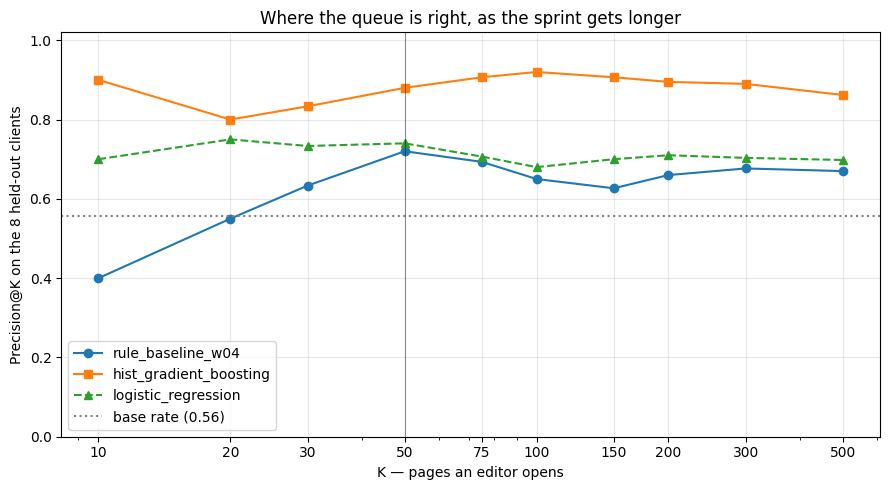

,P@10,P@20,P@30,P@50,P@75,P@100,P@150,P@200,P@300,P@500
rule_baseline_w04,0.4,0.55,0.633,0.72,0.693,0.65,0.627,0.660,0.677,0.670
logistic_regression,0.7,0.75,0.733,0.74,0.707,0.68,0.700,0.710,0.703,0.698
decision_tree_d3,0.8,0.75,0.767,0.80,0.720,0.74,0.727,0.720,0.723,0.734
random_forest,1.0,0.90,0.900,0.90,0.880,0.86,0.827,0.825,0.800,0.758
hist_gradient_boosting,0.9,0.80,0.833,0.88,0.907,0.92,0.907,0.895,0.890,0.862


In [8]:
import matplotlib.pyplot as plt

ks = [10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
fig, ax = plt.subplots(figsize=(9, 5))
for name, style in [("rule_baseline_w04", "o-"), (chosen_name, "s-"), ("logistic_regression", "^--")]:
    ax.plot(ks, [precision_at_k(y_test, test_scores[name], k) for k in ks], style, label=name)
ax.axhline(y_test.mean(), color="grey", linestyle=":", label=f"base rate ({y_test.mean():.2f})")
ax.axvline(50, color="black", linewidth=0.8, alpha=0.4)
ax.set_xscale("log")
ax.set_xticks(ks)
ax.set_xticklabels(ks)
ax.set_xlabel("K — pages an editor opens")
ax.set_ylabel("Precision@K on the 8 held-out clients")
ax.set_title("Where the queue is right, as the sprint gets longer")
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

curve = pd.DataFrame(
    {name: [round(precision_at_k(y_test, test_scores[name], k), 3) for k in ks]
     for name in ["rule_baseline_w04", "logistic_regression", "decision_tree_d3", "random_forest", "hist_gradient_boosting"]},
    index=[f"P@{k}" for k in ks],
).T
display(curve)

## 4. Errors and interpretation

A metric without error analysis is decoration. Five questions, in order:

1. **What does the score lean on?** — permutation importance on the held-out clients (shuffle a column, watch average precision fall). Read with suspicion: a single column that carries almost everything is usually leakage, not insight.
2. **Is the top feature measuring what I think it measures?** — follow it until it either survives or turns out to be an artefact of how the label is defined.
3. **Where is it most wrong?** — by content type, by position bucket, by visibility bucket, and per held-out client, because "the model is 80% right" can hide "it is useless on two of eight sites".
4. **What do the wrong ones look like?** — three concrete false positives from the top of the queue and the costly misses at the bottom, with their numbers.
5. **What kind of work sits at the top?** — K-Means on the top of the queue, k picked by silhouette (with a minimum archetype size), clusters named by hand after reading their profiles, so each queued page can carry an action and a reason code.

In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    fitted[chosen_name], X_test, y_test,
    scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1,
)
importance = (
    pd.DataFrame({"feature": X_test.columns, "drop_in_avg_precision": perm.importances_mean, "sd": perm.importances_std})
    .sort_values("drop_in_avg_precision", ascending=False)
    .head(12)
    .reset_index(drop=True)
    .round(4)
)
print(f"permutation importance — {chosen_name}, held-out clients, average precision, 5 shuffles each:")
display(importance)

top_share = importance["drop_in_avg_precision"].iloc[0] / importance["drop_in_avg_precision"].clip(lower=0).sum()
print(f"top feature carries {top_share:.0%} of the measured importance mass — "
      f"{'suspicious: check for leakage' if top_share > 0.6 else 'spread across several signals, no single give-away column'}")

permutation importance — hist_gradient_boosting, held-out clients, average precision, 5 shuffles each:


,feature,drop_in_avg_precision,sd
0,days_with_impressions,0.1523,0.0038
1,content_age_days,0.0555,0.0050
2,impressions_per_active_day,0.0259,0.0020
3,scroll_rate,0.0253,0.0043
4,avg_position,0.0247,0.0041
5,ctr,0.0241,0.0021
6,stale_share_of_life,0.0107,0.0041
7,log_impressions_90d,0.0106,0.0022
8,log_pageviews_90d,0.0051,0.0016
9,engagement_rate,0.0040,0.0008


top feature carries 44% of the measured importance mass — spread across several signals, no single give-away column


### Following the top feature: is this decay, or is it measurability?

`days_with_impressions` (how many of the 90 days the page appeared in search at all) dominates the importance table, and it is not a decay signal — it is a *measurability* signal. The label is mechanical about this: `trend_direction` can only be `down` when the previous 30-day window had impressions to fall from. A page with a handful of active days lands in `new` or `flat` and is a guaranteed 0. So part of what the model "predicts" is simply **which pages are eligible to be labelled declining**.

That is not leakage — every one of those columns is knowable before the decision — but it is a weaker claim than "the model spots decay". The check below quantifies it, then re-scores both the rule and the model on the **eligible** pages only (`impressions_prev_30d > 0`), which is the population an editor would actually be triaging. Nothing is retrained on that slice; it is the same fitted model, read on a fairer sub-population.

In [10]:
eligibility = lane_test.assign(
    history_bucket=pd.cut(lane_test["days_with_impressions"], bins=[-1, 4, 20, 60, 90],
                          labels=["0-4 days", "5-20", "21-60", "61-90"]),
    could_be_labelled_down=(lane_test["impressions_prev_30d"] > 0),
)
print("the label's mechanics: a page with almost no search history cannot be 'down'")
display(
    eligibility.groupby("history_bucket", observed=True)
    .agg(pages=("content_id", "size"),
         label_rate=("is_declining_label", "mean"),
         share_with_prev30_impressions=("could_be_labelled_down", "mean"))
    .round(3)
)
print("movement bucket by search-history depth (0-4 active days):")
display(
    eligibility[eligibility["history_bucket"] == "0-4 days"]["trend_direction"]
    .value_counts(normalize=True).round(3).to_frame("share")
)

eligible = eligibility["could_be_labelled_down"].to_numpy()
print()
print(f"eligible pages (prev-30d impressions > 0): {eligible.sum():,} of {len(eligible):,} "
      f"({eligible.mean():.1%}) — base rate inside that slice: {y_test[eligible].mean():.3f}")
robust = pd.DataFrame(
    [
        evaluate("rule_baseline_w04 — eligible pages only", y_test[eligible], test_scores["rule_baseline_w04"][eligible]),
        evaluate(f"{chosen_name} — eligible pages only", y_test[eligible], test_scores[chosen_name][eligible]),
        evaluate("rule_baseline_w04 — all held-out pages", y_test, test_scores["rule_baseline_w04"]),
        evaluate(f"{chosen_name} — all held-out pages", y_test, test_scores[chosen_name]),
    ]
).set_index("ranker").round(3)
display(robust)
print("if the lead survives on the eligible slice, the win is not only 'the model hides unmeasurable pages'.")

the label's mechanics: a page with almost no search history cannot be 'down'


,pages,label_rate,share_with_prev30_impressions
history_bucket,,,
0-4 days,789,0.146,0.279
5-20,584,0.421,0.788
21-60,1142,0.560,0.863
61-90,3111,0.688,1.000


movement bucket by search-history depth (0-4 active days):


,share
trend_direction,
new,0.617
down,0.146
flat,0.104
stable,0.093
up,0.041



eligible pages (prev-30d impressions > 0): 4,776 of 5,626 (84.9%) — base rate inside that slice: 0.657


,P@20,P@50,P@100,Recall@50,ROC-AUC,AvgPrec
ranker,,,,,,
rule_baseline_w04 — eligible pages only,0.55,0.72,0.65,0.011,0.609,0.713
hist_gradient_boosting — eligible pages only,0.80,0.88,0.93,0.014,0.665,0.781
rule_baseline_w04 — all held-out pages,0.55,0.72,0.65,0.011,0.699,0.690
hist_gradient_boosting — all held-out pages,0.80,0.88,0.92,0.014,0.742,0.761


if the lead survives on the eligible slice, the win is not only 'the model hides unmeasurable pages'.


### Where it is wrong — slices, not averages

In [11]:
errors = lane_test[[
    "content_id", "client_id", "content_type", "main_intent", "impressions_90d", "clicks_90d",
    "sessions_90d", "avg_position", "ctr", "engagement_rate", "scroll_rate", "word_count",
    "content_age_days", "days_since_last_update", "trend_direction", "is_declining_label",
]].copy()
errors["model_score"] = test_scores[chosen_name]
errors["baseline_score"] = test_scores["rule_baseline_w04"]
errors["model_rank"] = errors["model_score"].rank(ascending=False, method="first").astype(int)
errors["in_top_50"] = errors["model_rank"] <= 50
errors["predicted_positive"] = (errors["model_score"] >= 0.5).astype(int)
errors["correct"] = (errors["predicted_positive"] == errors["is_declining_label"]).astype(int)
errors["position_bucket"] = pd.cut(
    errors["avg_position"].replace(0, np.nan), bins=[0, 3, 10, 20, 50, 1000],
    labels=["top_3", "page_1", "11-20", "21-50", "deep"],
).cat.add_categories("no_position_data").fillna("no_position_data")
errors["visibility_bucket"] = pd.cut(
    errors["impressions_90d"], bins=[0, 100, 500, 3000, 30000, np.inf],
    labels=["<100", "100-500", "500-3k", "3k-30k", "30k+"],
)


def slice_report(column):
    out = (
        errors.groupby(column, observed=True)
        .agg(pages=("content_id", "size"),
             actual_rate=("is_declining_label", "mean"),
             mean_score=("model_score", "mean"),
             accuracy_at_0_5=("correct", "mean"),
             in_top_50=("in_top_50", "sum"))
        .round(3)
    )
    out["score_minus_actual"] = (out["mean_score"] - out["actual_rate"]).round(3)
    return out


for column in ["content_type", "position_bucket", "visibility_bucket"]:
    print(f"--- by {column} " + "-" * (70 - len(column)))
    display(slice_report(column))

print("--- per held-out client (its own top-20 queue) " + "-" * 30)
per_client_rows = []
for client, chunk in errors.groupby("client_id"):
    k_client = min(20, len(chunk))
    per_client_rows.append({
        "client": client[-6:],
        "pages": len(chunk),
        "actual_rate": round(chunk["is_declining_label"].mean(), 3),
        f"model P@{k_client}": round(precision_at_k(chunk["is_declining_label"], chunk["model_score"], k_client), 3),
        f"rule P@{k_client}": round(precision_at_k(chunk["is_declining_label"], chunk["baseline_score"], k_client), 3),
        "pages_in_global_top_50": int(chunk["in_top_50"].sum()),
    })
display(pd.DataFrame(per_client_rows).sort_values("actual_rate").reset_index(drop=True))

print("--- score decile vs reality (is the ordering monotone?) " + "-" * 22)
errors["score_decile"] = pd.qcut(errors["model_score"], 10, labels=False, duplicates="drop") + 1
display(
    errors.groupby("score_decile")
    .agg(pages=("content_id", "size"), actual_rate=("is_declining_label", "mean"),
         mean_score=("model_score", "mean"), median_impressions=("impressions_90d", "median"))
    .round(3)
)

--- by content_type ----------------------------------------------------------


,pages,actual_rate,mean_score,accuracy_at_0_5,in_top_50,score_minus_actual
content_type,,,,,,
feedly article,999,0.216,0.320,0.752,2,0.104
keyword article,4627,0.632,0.564,0.663,48,-0.068


--- by position_bucket -------------------------------------------------------


,pages,actual_rate,mean_score,accuracy_at_0_5,in_top_50,score_minus_actual
position_bucket,,,,,,
top_3,308,0.386,0.426,0.802,28,0.040
page_1,2000,0.562,0.570,0.654,9,0.008
11-20,1331,0.669,0.605,0.660,4,-0.064
21-50,1374,0.647,0.530,0.624,9,-0.117
deep,329,0.347,0.362,0.745,0,0.015
no_position_data,284,0.007,0.022,0.993,0,0.015


--- by visibility_bucket -----------------------------------------------------


,pages,actual_rate,mean_score,accuracy_at_0_5,in_top_50,score_minus_actual
visibility_bucket,,,,,,
<100,1761,0.332,0.379,0.712,15,0.047
100-500,1189,0.590,0.589,0.712,12,-0.001
500-3k,1657,0.711,0.618,0.681,20,-0.093
3k-30k,961,0.677,0.536,0.588,3,-0.141
30k+,58,0.414,0.405,0.483,0,-0.009


--- per held-out client (its own top-20 queue) ------------------------------


,client,pages,actual_rate,model P@20,rule P@20,pages_in_global_top_50
0,4232cd,649,0.194,0.10,0.10,0
1,5e3a26,1106,0.220,0.60,0.45,2
2,4c6ff0,254,0.386,0.60,0.65,8
3,ced1de,43,0.419,0.50,0.40,0
4,fabef1,1031,0.542,0.95,0.15,6
5,ab7c34,118,0.619,0.85,0.90,12
6,f1b21c,158,0.766,0.95,0.80,0
7,a35f04,2267,0.839,0.95,0.60,22


--- score decile vs reality (is the ordering monotone?) ----------------------


,pages,actual_rate,mean_score,median_impressions
score_decile,,,,
1,563,0.089,0.077,1.0
2,563,0.321,0.262,134.0
3,562,0.447,0.368,325.0
4,563,0.533,0.458,939.0
5,562,0.580,0.530,962.0
6,563,0.604,0.591,494.0
7,562,0.655,0.645,647.5
8,563,0.725,0.698,679.0
9,562,0.778,0.751,699.0


### Three concrete wrong cases — and the misses that would cost the most

False positives at the top of the queue waste editor hours. False negatives with high visibility are the expensive kind: a page with real demand that is sliding and never gets opened. `trend_direction` is printed here as *diagnosis only* — it is the answer key, never a feature.

In [12]:
show_cols = ["content_type", "impressions_90d", "clicks_90d", "ctr", "avg_position",
             "days_since_last_update", "content_age_days", "word_count", "engagement_rate",
             "model_rank", "model_score", "trend_direction", "is_declining_label"]

top_queue = errors.nsmallest(50, "model_rank")
false_positives = top_queue[top_queue["is_declining_label"] == 0].head(3)
print(f"top-50 queue: {int(top_queue['is_declining_label'].sum())} real declines, "
      f"{int((1 - top_queue['is_declining_label']).sum())} wasted opens")
print()
print("three wasted opens (ranked high, label says not declining):")
display(false_positives[show_cols].round(3))
if len(false_positives):
    print("their actual movement bucket:", false_positives["trend_direction"].tolist())
    print("reason codes my Week-4 rule would print for them:")
    for _, row in false_positives.iterrows():
        print(f"  rank {row['model_rank']:>3}: {baseline_reason_codes(row)}")

print()
print("the costly misses — declining pages with real demand that the queue ranked far down:")
misses = errors[(errors["is_declining_label"] == 1) & (errors["impressions_90d"] >= 1000)].nlargest(3, "model_rank")
display(misses[show_cols].round(3))

print()
print("wasted opens by movement bucket — what the label calls the 'wrong' picks:")
display(
    top_queue[top_queue["is_declining_label"] == 0]["trend_direction"]
    .value_counts()
    .rename_axis("trend_direction")
    .to_frame("pages_in_top_50")
)

top-50 queue: 44 real declines, 6 wasted opens

three wasted opens (ranked high, label says not declining):


,content_type,impressions_90d,clicks_90d,ctr,avg_position,days_since_last_update,content_age_days,word_count,engagement_rate,model_rank,model_score,trend_direction,is_declining_label
3122,keyword article,21,0,0.00,45.0,1,91,3017.0,0.0,2,0.976,stable,0
2694,keyword article,280,1,0.36,12.3,8,91,2672.0,0.0,13,0.921,up,0
2511,keyword article,3216,3,0.09,2.6,20,95,2661.0,0.0,18,0.918,up,0


their actual movement bucket: ['stable', 'up', 'up']
reason codes my Week-4 rule would print for them:
  rank   2: general_refresh_review
  rank  13: general_refresh_review
  rank  18: low_ctr_visible_page

the costly misses — declining pages with real demand that the queue ranked far down:


,content_type,impressions_90d,clicks_90d,ctr,avg_position,days_since_last_update,content_age_days,word_count,engagement_rate,model_rank,model_score,trend_direction,is_declining_label
1306,keyword article,3141,0,0.00,45.5,104,463,NaN,0.00,5210,0.117,down,1
1951,keyword article,5472,91,1.66,4.7,104,310,1608.0,8.03,5206,0.120,down,1
685,keyword article,3967,0,0.00,43.2,104,463,NaN,10.00,5187,0.131,down,1



wasted opens by movement bucket — what the label calls the 'wrong' picks:


,pages_in_top_50
trend_direction,
stable,3
up,3


### What kind of work is in the queue? (K-Means, named by hand)

The queue says *which* page; an editor still asks *what do I do with it?* K-Means over six interpretable signals on the top 100 of the model queue, k chosen by silhouette, then the clusters read and named from their profile table. This is description, not prediction — no label goes into the clustering.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_cols = ["log_impressions_90d", "avg_position", "ctr", "days_since_last_update",
                "days_with_impressions", "word_count"]
top_n = 150
top_idx = errors.nsmallest(top_n, "model_rank").index
Z_raw = X_test.reset_index(drop=True).loc[top_idx, cluster_cols]
Z = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(Z_raw))

MIN_CLUSTER_SHARE = 0.08   # an archetype smaller than 8% of the queue is not an archetype
sil, sizes = {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    sil[k] = round(float(silhouette_score(Z, km.labels_)), 3)
    sizes[k] = int(np.bincount(km.labels_).min())
print("silhouette by k (higher = better separated):", sil)
print("smallest cluster size by k:", sizes)
usable = [k for k in sil if sizes[k] >= MIN_CLUSTER_SHARE * top_n]
best_k = max(usable, key=sil.get) if usable else max(sil, key=sil.get)
print(f"chosen k = {best_k}  (best silhouette among k whose smallest cluster holds >= {MIN_CLUSTER_SHARE:.0%} of the queue)")
print("silhouette alone keeps rising as k grows by shaving off 2-page slivers; a named archetype has to be big enough to staff.")

km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(Z)
queue = errors.loc[top_idx].copy()
queue["cluster"] = km.labels_

queue["days_with_impressions"] = X_test.reset_index(drop=True).loc[top_idx, "days_with_impressions"]
profile = (
    queue.groupby("cluster")
    .agg(pages=("content_id", "size"),
         median_impressions=("impressions_90d", "median"),
         median_days_with_impressions=("days_with_impressions", "median"),
         median_position=("avg_position", "median"),
         median_ctr=("ctr", "median"),
         median_days_since_update=("days_since_last_update", "median"),
         median_word_count=("word_count", "median"),
         actual_decline_rate=("is_declining_label", "mean"))
    .round(2)
)
display(profile)


def name_cluster(row, overall):
    """Auto-draft a name from the profile; the markdown below names them for real."""
    tags = []
    tags.append("high-visibility" if row["median_impressions"] >= overall["median_impressions"] else "low-visibility")
    if pd.notna(row["median_position"]) and row["median_position"] > 0:
        tags.append("page-1" if row["median_position"] <= 10 else "deep-ranking")
    else:
        tags.append("no-position-data")
    tags.append("shows-up-daily" if row["median_days_with_impressions"] >= 60 else "intermittent-in-search")
    tags.append("stale" if row["median_days_since_update"] >= overall["median_days_since_update"] else "recently-updated")
    return " / ".join(tags)


overall = profile.median()
profile["draft_name"] = [name_cluster(r, overall) for _, r in profile.iterrows()]
display(profile[["pages", "actual_decline_rate", "draft_name"]])

print()
print("top-50 precision inside each cluster (does one archetype carry the wins?):")
display(
    queue[queue["model_rank"] <= 50]
    .groupby("cluster")
    .agg(pages_in_top_50=("content_id", "size"), precision=("is_declining_label", "mean"))
    .round(3)
)

silhouette by k (higher = better separated): {2: 0.388, 3: 0.374, 4: 0.399, 5: 0.421, 6: 0.434}
smallest cluster size by k: {2: 34, 3: 26, 4: 6, 5: 5, 6: 5}
chosen k = 2  (best silhouette among k whose smallest cluster holds >= 8% of the queue)
silhouette alone keeps rising as k grows by shaving off 2-page slivers; a named archetype has to be big enough to staff.


,pages,median_impressions,median_days_with_impressions,median_position,median_ctr,median_days_since_update,median_word_count,actual_decline_rate
cluster,,,,,,,,
0,34,39.5,24.5,20.45,0.0,4.5,2803.5,0.85
1,116,685.0,68.0,3.60,0.0,20.0,1580.5,0.92


,pages,actual_decline_rate,draft_name
cluster,,,
0,34,0.85,low-visibility / deep-ranking / intermittent-i...
1,116,0.92,high-visibility / page-1 / shows-up-daily / stale



top-50 precision inside each cluster (does one archetype carry the wins?):


,pages_in_top_50,precision
cluster,,
0,15,0.800
1,35,0.914


### Leakage sanity check — the numbers the table would show if I cheated

Two runs I throw away on purpose. First the label ingredient itself (`trend_pct`) in a depth-2 tree; second the sibling last-30/prev-30 click and session windows that I excluded in section 1. If those columns make the score jump, the exclusion list was right — and it also calibrates what "too good" looks like on this dataset.

In [14]:
def score_with_extra(extra_columns, model_key, tag):
    X_plus_train = X_train.copy()
    X_plus_test = X_test.copy()
    for column in extra_columns:
        X_plus_train[column] = lane.loc[train_mask, column].to_numpy()
        X_plus_test[column] = lane.loc[test_mask, column].to_numpy()

    global NUMERIC_FEATURES
    saved = NUMERIC_FEATURES
    NUMERIC_FEATURES = saved + list(extra_columns)
    try:
        model = build_models()[model_key]
        model.fit(X_plus_train, y_train)
        scores = model.predict_proba(X_plus_test)[:, 1]
    finally:
        NUMERIC_FEATURES = saved
    return evaluate(tag, y_test, scores)


leak_rows = [
    evaluate(f"HONEST — {chosen_name}, no label windows", y_test, test_scores[chosen_name]),
    score_with_extra(["trend_pct"], "decision_tree_d3", "TRAP — depth-3 tree + trend_pct (label ingredient)"),
    score_with_extra(
        ["clicks_last_30d", "clicks_prev_30d", "sessions_last_30d", "sessions_prev_30d"],
        chosen_name,
        f"NEAR-LEAK — {chosen_name} + last30/prev30 click & session windows",
    ),
]
display(pd.DataFrame(leak_rows).set_index("ranker").round(3))
print("both cheating rows are deleted. The honest row is the one in section 3's table.")
print("reading: anything near-perfect on this dataset means a label window walked into the features.")

,P@20,P@50,P@100,Recall@50,ROC-AUC,AvgPrec
ranker,,,,,,
"HONEST — hist_gradient_boosting, no label windows",0.80,0.88,0.92,0.014,0.742,0.761
TRAP — depth-3 tree + trend_pct (label ingredient),1.00,1.00,1.00,0.016,1.000,1.000
NEAR-LEAK — hist_gradient_boosting + last30/prev30 click & session windows,0.95,0.90,0.92,0.014,0.793,0.802


both cheating rows are deleted. The honest row is the one in section 3's table.
reading: anything near-perfect on this dataset means a label window walked into the features.


## 5. Verdict — model vs baseline, and what the errors look like

**Headline, one line:** on the same 8 held-out clients, the same label and the same metric, my Week-4 rule scores **Precision@50 = 0.720** and the selected model scores **0.880** — a **+0.16** absolute gain, **1.22×** the rule, against a test base rate of **0.558**. Selection happened on grouped cross-validation (CV Precision@50 **0.848 ± 0.041** for the model vs **0.408 ± 0.116** for the rule, model ahead in **5/5** folds, mean gap **+0.44**), and the held-out clients were scored exactly once. Bootstrapping the held-out rows puts the model at **0.80–0.96** and the rule at **0.58–0.82**, with the model ahead in **97.5%** of resamples. Measured, on this proxy label — not a forecast.

**Complexity barely earned its seat.** Gradient boosting beat plain logistic regression by **+0.028** mean Precision@50 across folds with a fold-to-fold sd of **0.066**, winning only **3 of 5** folds. So the finding I will defend is *"a learned score beats my hand rule"*, not *"boosting is the right learner"*. The readable alternatives still clear the rule (depth-3 tree 0.800, logistic regression 0.740), and I would happily ship the tree or the linear model next to the booster — the queue it produces is arguable with a strategist, which the booster's is not.

**The rule is not bad; it is unstable.** It scored 0.720 on these holdout clients but ranged **0.30–0.62** across the five grouped folds. Its quality depends on which clients it is pointed at. That instability is exactly why the split is grouped and why one number on one slice is never the whole claim.

**What the model leans on — and the honest discount.** Permutation importance on the holdout: `days_with_impressions` (−0.152 average precision when shuffled, ~44% of the measured mass), then `content_age_days` (−0.056), then `impressions_per_active_day`, `scroll_rate`, `avg_position`, `ctr` at roughly −0.025 each. The top signal is **measurability, not decay**: a page needs impressions in the previous 30-day window before it *can* be bucketed `down`, so pages with ≤4 active search days are 62% `new` and only 14.6% declining. Re-scoring the same fitted model on the 4,776 pages that were eligible for the label keeps the top-50 lead intact (**0.88 vs 0.72**), but ROC-AUC falls from 0.742 to 0.665 — meaning a real share of the *whole-list* ordering was "which pages are measurable at all", and only the top of the list is about decay. That discount belongs in every sentence I write about this model.

**What the errors look like.** 44 of the top 50 are real declines. The 6 wasted opens are 3 `stable` and 3 `up` pages, all young (91–95 days old), updated within the last 1–20 days, with zero recorded engagement — the model reads "already established in search, young, no engagement evidence" as decline. The costly misses are the mirror image: pages with 3,000–5,500 impressions, 310–463 days old, last updated 104 days ago, parked around rank 5,200 of 5,626. The depth-3 tree names the mechanism out loud — its only strongly-declining branch is `days_with_impressions > 4.5 AND content_age_days <= 234`, so *older* declining pages get pushed down by construction. The slice tables agree: the model is most under-confident on 3k–30k impression pages (mean score 0.14 below the actual rate) and on positions 21–50 (0.12 below).

**Where I would not ship it.** Per client, the model beats or matches the rule on 7 of 8 held-out clients, but on the lowest-decline client (19% base rate) its own top-20 precision is **0.10 — below that client's base rate**. A single global queue is therefore not safe for every site; the queue needs a per-client view (and a floor) before an editor trusts it.

**What kind of work is in the queue (clusters).** Silhouette keeps rising to k=6 only by shaving off 5-page slivers, so with a minimum archetype size the honest answer is **k=2** on the top 150:
- **"Visible page-1 workhorses"** — 116 pages, median 685 impressions/90d, position 3.6, present in search 68 of 90 days, updated 20 days ago, ~1,580 words; 92% actually declining, precision 0.914 inside the top 50. Action: *refresh and expand* — real demand, real ranking, slipping.
- **"Long but invisible"** — 34 pages, median 39 impressions/90d, position 20.5, present only 24 of 90 days, ~2,800 words; 85% declining, precision 0.800. Action: *not a refresh* — that is an intent/keyword mismatch or a consolidation candidate. Writing more words on these would be the expensive mistake.

**Leakage check.** Letting `trend_pct` in makes every metric 1.000 — that is what cheating looks like on this dataset. The sibling last-30/prev-30 click and session windows are subtler: 0.90 Precision@50 and 0.793 ROC-AUC versus the honest 0.88 / 0.742. Small, real, and enough to justify keeping them out. Both runs are deleted; the honest number is the one in the section 3 table.

**What this does and does not claim.** Observed and measured: on this 30,000-page snapshot, with a client-grouped holdout, a learned score ranks already-declining pages into a 50-page review queue more reliably than my hand rule. Not claimed: that a page will decline next month (this label is a current-window movement bucket, not a future outcome) and not that refreshing a page causes recovery (nothing here records an intervention). Week 6 moves the label to a real past→future window on the warehouse daily facts, where `days_with_impressions` has to be earned inside the feature window and the measurability discount above can finally be tested instead of estimated.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

**Recap for the person who asks "did it beat the baseline?"** Yes, on the same 8 held-out clients, the same proxy label and the same metric, computed in this one notebook run: rule 0.720 → model 0.880 Precision@50 (base rate 0.558), selected on grouped cross-validation and confirmed in 5/5 folds. The win is real and the reason is partly unglamorous: a third of the ordering is the model learning which pages are measurable enough to be labelled at all. The top of the queue splits into two archetypes that want two different actions, and on one of eight clients the queue is worse than that client's own base rate.